# A live feedback experiment

This notebook runs a complete closed-loop experiment on a virtual microscope: the pipeline segments and tracks cells on every frame, and a stimulator decides where to shine light. In the simulation, illuminated cells move toward the light. Along the way you meet the four objects that every faro experiment uses:

| Object | Job |
|--------|-----|
| **Microscope** | talks to the hardware (here: a simulation) |
| **Pipeline** | segments, tracks and measures cells on every frame, and decides where to stimulate |
| **Controller** | sends acquisition events to the microscope and frames to the pipeline |
| **Writer** | stores images and masks on disk |

You will write your own segmentator, feature extractor and stimulator, run a three-phase experiment (baseline, stimulation, recovery) from napari, and check that the cells responded. The structure is the same as the [live experiment template](../templates/live_experiment/experiment.ipynb), so the template will look familiar afterwards.

Nothing here needs real hardware. Install faro with the virtual microscope:

```
uv sync --extra virtual-microscope
```

The [README](../README.md) is the reference; links in this notebook point to the matching section.

## Parameters

Everything you may want to change lives in one cell.

In [1]:
INTERVAL_S = 1.0        # seconds between frames
N_BASELINE = 10         # frames without stimulation
N_STIM = 30             # frames with stimulation
N_RECOVERY = 10         # frames after stimulation
N_EXTRA = 10            # frames appended while the experiment is running
STIM_FRACTION = 0.2     # illuminate the top 20 % of each cell

## 1. Connect to the virtual microscope

The virtual microscope runs entirely in Python. `core` is a [pymmcore-plus](https://github.com/pymmcore-plus/pymmcore-plus) core, so it has the same API as a real Micro-Manager microscope. The optogenetic backend has a camera, a stage, channels and an SLM (spatial light modulator) that faro uses as a DMD. `mic` wraps the core in a faro `Microscope`; this is where scope-specific behaviour lives, and `init_scope()` finds the SLM.

If you have Micro-Manager installed, its demo devices work too: `from faro.microscope.demo import MMDemo; mic = MMDemo()`. They cannot respond to stimulation, so the cells will not move.

In [2]:
from virtual_microscope.backends.optogenetic import setup_optogenetic
from faro.microscope.simulation import UniMMCoreSimulation
import faro.core.utils as utils

core, sim = setup_optogenetic()
mic = UniMMCoreSimulation(mmc=core)
mic.init_scope()
utils.print_configs(core)

Config Groups
└── Channel
    ├── DAPI
    ├── membrane
    └── phase-contrast

## 2. Open napari

faro microscopes work with the stock
[napari-micromanager](https://github.com/pymmcore-plus/napari-micromanager)
plugin. Pass `mic.mmc` to its main window and you get live view, stage control
and the position list for free. The `ExperimentStatusWidget` shows progress,
lag and errors once we bind it to a controller in step 7.

Skip this cell if you want to run without a GUI; nothing below depends on it.

In [3]:
import napari
from napari_micromanager import MainWindow
from faro.widgets import ExperimentStatusWidget

viewer = napari.Viewer()
mm_widget = MainWindow(viewer, mmcore=mic.mmc)
viewer.window.add_dock_widget(mm_widget, name="napari-micromanager")

status_widget = ExperimentStatusWidget()
viewer.window.add_dock_widget(status_widget, name="experiment status", area="right")

Press **Live** in the napari-micromanager toolbar to stream the virtual camera. The next cell does the same from code and puts a screenshot of the window into this notebook; skip it when you work interactively.

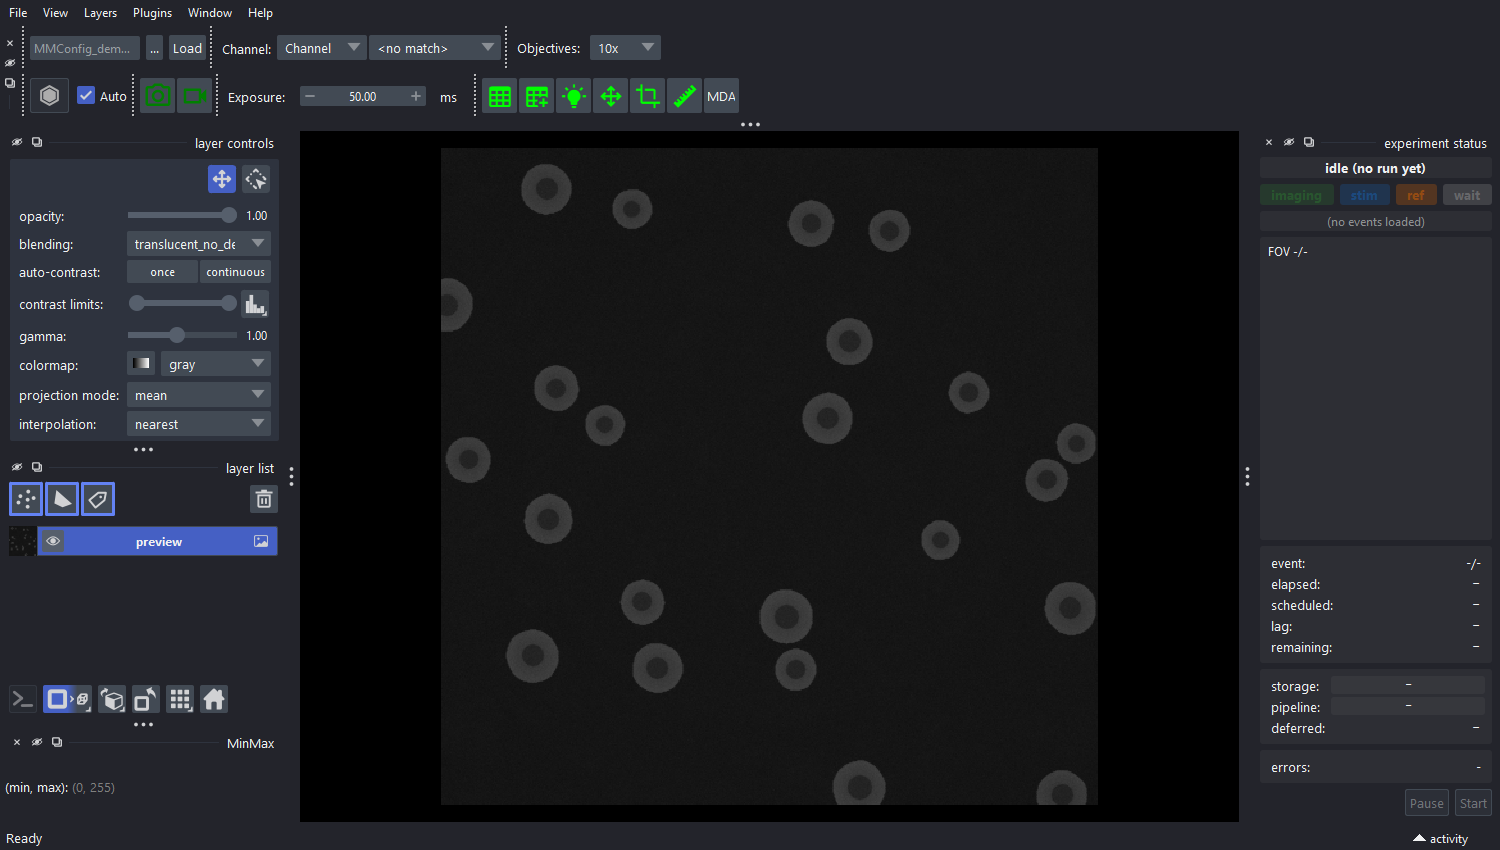

In [4]:
import time
from napari.utils import nbscreenshot
from qtpy.QtWidgets import QApplication

core.startContinuousSequenceAcquisition(0)          # same as pressing Live
t0 = time.time()
while time.time() - t0 < 2:                          # let a few frames reach the preview
    QApplication.processEvents()
core.stopSequenceAcquisition()
nbscreenshot(viewer, canvas_only=False)

## 3. Segmentation

A segmentator turns one image into a label image: `0` is background, every
cell gets its own integer. Subclass `Segmentator` and implement `segment`.
Real experiments use Cellpose or StarDist (see the `cellpose` and `stardist`
extras); here a watershed on a blurred threshold is enough and fast.

`SegmentationMethod` gives the segmentation a name and tells the pipeline which
channel to segment. You can list several methods, for example one for nuclei
and one for whole cells.

See [Writing your own components](../README.md#writing-your-own-components).

In [5]:
import numpy as np
from scipy import ndimage
from skimage.feature import peak_local_max
from skimage.filters import gaussian, threshold_otsu
from skimage.measure import label
from skimage.segmentation import watershed

from faro.core.data_structures import SegmentationMethod
from faro.segmentation.base import Segmentator


class WatershedSegmentator(Segmentator):
    """Blur, Otsu threshold, distance transform, watershed."""

    def segment(self, image: np.ndarray) -> np.ndarray:
        blurred = gaussian(image, sigma=3)
        binary = blurred > threshold_otsu(blurred)
        distance = ndimage.distance_transform_edt(binary)
        coords = peak_local_max(distance, min_distance=20, labels=binary)
        markers = np.zeros(distance.shape, dtype=bool)
        markers[tuple(coords.T)] = True
        return watershed(-distance, label(markers), mask=binary)


segmentators = [
    SegmentationMethod(
        name="labels",
        segmentation_class=WatershedSegmentator(),
        use_channel=0,
        save_tracked=True,
    )
]

## 4. Tracking

The tracker links cells between frames and assigns each one a `particle` id.
The key parameter of `TrackerTrackpy` is `search_range`: the largest distance
in pixels a cell centroid may move between two frames.

In [6]:
from faro.tracking.trackpy import TrackerTrackpy

tracker = TrackerTrackpy(search_range=15)

## 5. Feature extraction

The feature extractor measures every cell in every frame. It receives the
label images (a dict keyed by segmentation name) and the raw image as a
`(channels, y, x)` stack, and returns a DataFrame with one row per label. The
pipeline merges these columns into the tracks. `regionprops_table` is a good
start; biosensor readouts such as ERK-KTR ratios go here too.

In [7]:
import pandas as pd
from skimage.measure import regionprops_table

from faro.feature_extraction.base import FeatureExtractor


class AreaAndIntensity(FeatureExtractor):
    def __init__(self, used_mask, channel=0):
        self.used_mask = used_mask
        self.channel = channel
        super().__init__()

    def extract_features(self, labels, image, df_tracked=None, metadata=None):
        table = regionprops_table(
            labels[self.used_mask],
            intensity_image=image[self.channel],
            properties=["label", "area", "mean_intensity"],
        )
        return pd.DataFrame(table), None


feature_extractor = AreaAndIntensity("labels")

## 6. Stimulation

The stimulator decides where to illuminate. It returns a mask with the same
shape as the image; `1` means light on. Three base classes exist:

- `Stim` receives only metadata (frame index, image shape).
- `StimWithImage` also receives the raw image.
- `StimWithPipeline` also receives the label images and the tracks.

`StimUp` illuminates the top edge of every cell. In the simulation this pulls
the cells upward, like an optogenetic Rac activator would. Because it has the
tracks, a stimulator can also treat each cell differently, for example by
`particle` id.

In [8]:
from skimage.measure import regionprops
from skimage.morphology import dilation, disk

from faro.stimulation.base import StimWithPipeline


class StimUp(StimWithPipeline):
    """Illuminate the top `fraction` of each cell, dilated by 3 px."""

    def __init__(self, fraction):
        self.fraction = fraction

    def get_stim_mask(self, label_images, metadata=None, img=None, tracks=None):
        labels = label_images["labels"]
        stim_mask = np.zeros(labels.shape, dtype=np.uint8)
        for prop in regionprops(labels):
            minr, _, maxr, _ = prop.bbox
            y_cutoff = minr + self.fraction * (maxr - minr)
            rows, cols = np.where(labels == prop.label)
            top = rows < y_cutoff
            if not top.any():
                continue
            local = np.zeros_like(stim_mask)
            local[rows[top], cols[top]] = 1
            stim_mask = np.maximum(stim_mask, dilation(local, footprint=disk(3)))
        return stim_mask, None


stimulator = StimUp(fraction=STIM_FRACTION)

## 7. Assemble pipeline and controller

The writer stores raw frames, labels and stimulation masks in one OME-Zarr
store. The controller ties everything together. If you opened napari, bind
the status widget to the controller now.

In [9]:
import tempfile

from faro.core.controller import Controller
from faro.core.pipeline import ImageProcessingPipeline
from faro.core.writers import OmeZarrWriter

path = tempfile.mkdtemp(prefix="faro_live_experiment_")

pipeline = ImageProcessingPipeline(
    storage_path=path,
    segmentators=segmentators,
    feature_extractor=feature_extractor,
    tracker=tracker,
    stimulator=stimulator,
)
ctrl = Controller(mic, pipeline, writer=OmeZarrWriter(storage_path=path))
print("results go to", path)

Directory C:\Users\lh21x018\AppData\Local\Temp\faro_live_experiment_trmw9euj\tracks created 
results go to C:\Users\lh21x018\AppData\Local\Temp\faro_live_experiment_trmw9euj


In [10]:
status_widget.set_controller(ctrl)

## 8. Preview segmentation and stimulation mask

Snap one frame and run the segmentator and the stimulator on it. This is the
cheapest check that the pipeline does what you expect.

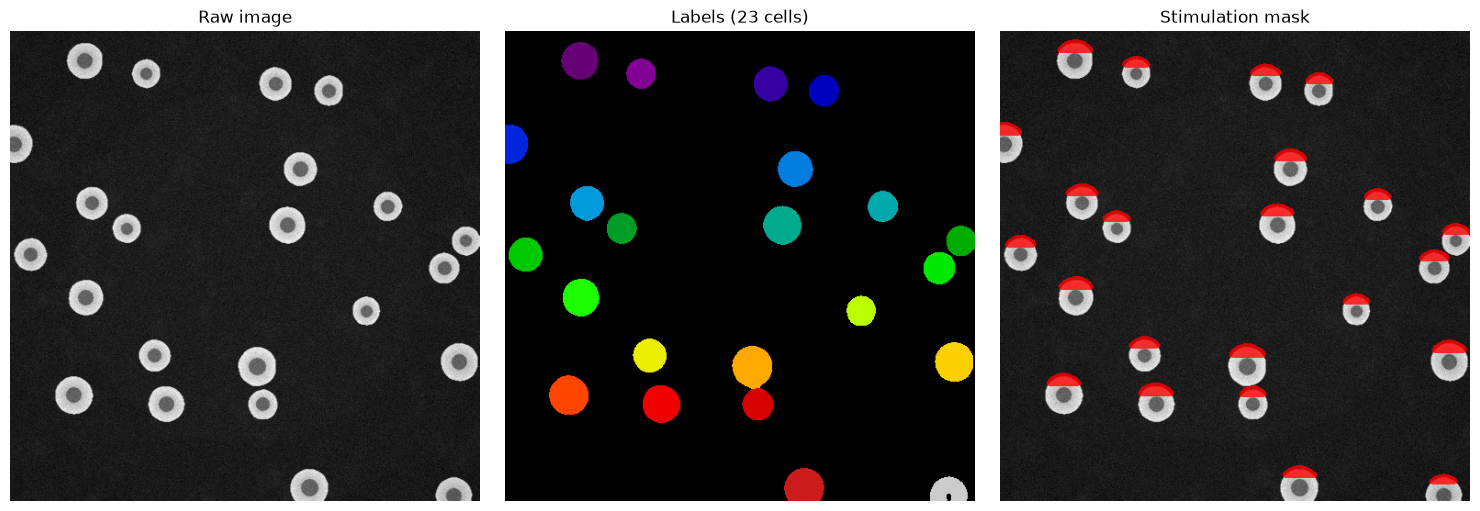

In [11]:
import matplotlib.pyplot as plt

core.setConfig("Channel", "phase-contrast")
core.snapImage()
test_img = core.getImage()
labels_preview = segmentators[0].segmentation_class.segment(test_img)
mask_preview, _ = stimulator.get_stim_mask({"labels": labels_preview}, metadata={})

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(test_img, cmap="gray")
axes[0].set_title("Raw image")
axes[1].imshow(labels_preview, cmap="nipy_spectral")
axes[1].set_title(f"Labels ({labels_preview.max()} cells)")
axes[2].imshow(test_img, cmap="gray")
axes[2].imshow(np.ma.masked_where(mask_preview == 0, mask_preview), cmap="autumn", alpha=0.8)
axes[2].set_title("Stimulation mask")
for ax in axes:
    ax.axis("off")
plt.tight_layout()

## 9. Build the event list

Three `RTMSequence` phases, joined with `combine(..., axis="t")`. Only the
middle phase has `stim_channels` and `stim_frames`. `rtm_metadata` travels with
every event and ends up in the tracks, so you can group by phase later.

See [Experiment Definition](../README.md#experiment-definition) and
[Stimulation](../README.md#stimulation) in the README.

In [12]:
from faro.core.data_structures import RTMSequence, combine
from faro.core.utils import events_to_dataframe

position = [{"x": 0.0, "y": 0.0, "z": 0.0}]
imaging = [{"config": "phase-contrast", "exposure": 50}]

baseline = RTMSequence(
    time_plan={"interval": INTERVAL_S, "loops": N_BASELINE},
    stage_positions=position,
    channels=imaging,
    rtm_metadata={"phase": "baseline"},
)
stim_phase = RTMSequence(
    time_plan={"interval": INTERVAL_S, "loops": N_STIM},
    stage_positions=position,
    channels=imaging,
    stim_channels=[{"config": "phase-contrast", "exposure": 50}],
    stim_frames=range(N_STIM),
    rtm_metadata={"phase": "stimulation"},
)
recovery = RTMSequence(
    time_plan={"interval": INTERVAL_S, "loops": N_RECOVERY},
    stage_positions=position,
    channels=imaging,
    rtm_metadata={"phase": "recovery"},
)

events = combine(baseline, stim_phase, recovery, axis="t")
df_events = events_to_dataframe(events)
print(f"{len(events)} events, stim on frames "
      f"{df_events[df_events['stim']]['timestep'].min()} to "
      f"{df_events[df_events['stim']]['timestep'].max()}")
df_events.head()

50 events, stim on frames 10 to 39


,fov,timestep,time,x_pos,y_pos,z_pos,channels,stim_channels,ref_channels,stim,ref,phase,stim_power,stim_exposure
0,0,0,0.0,0.0,0.0,0.0,"({'config': 'phase-contrast', 'exposure': 50.0...",(),(),False,False,baseline,NaN,NaN
1,0,1,1.0,0.0,0.0,0.0,"({'config': 'phase-contrast', 'exposure': 50.0...",(),(),False,False,baseline,NaN,NaN
2,0,2,2.0,0.0,0.0,0.0,"({'config': 'phase-contrast', 'exposure': 50.0...",(),(),False,False,baseline,NaN,NaN
3,0,3,3.0,0.0,0.0,0.0,"({'config': 'phase-contrast', 'exposure': 50.0...",(),(),False,False,baseline,NaN,NaN
4,0,4,4.0,0.0,0.0,0.0,"({'config': 'phase-contrast', 'exposure': 50.0...",(),(),False,False,baseline,NaN,NaN


## 10. Validate and load

`validate_events` checks that your components match their base-class signatures, that events carry the metadata the components need, and that the microscope knows every channel and can deliver every exposure. It returns `False` and prints a warning for each problem. Run it after every change to the pipeline or the event list.

`load_experiment` then stages the run: the status widget shows the phase strip and the event count, and its **Start** button becomes active.

See [Validation](../README.md#validation) in the README.

In [13]:
assert ctrl.validate_events(events), "fix the warnings above before running"
ctrl.load_experiment(events, stim_mode="current")

[RTMEvent(index={'t': 0, 'p': 0}, min_start_time=0.0, x_pos=0.0, y_pos=0.0, z_pos=0.0, metadata={'phase': 'baseline'}, channels=(Channel(config='phase-contrast', exposure=50.0, group='Channel'),)),
 RTMEvent(index={'t': 1, 'p': 0}, min_start_time=1.0, x_pos=0.0, y_pos=0.0, z_pos=0.0, metadata={'phase': 'baseline'}, channels=(Channel(config='phase-contrast', exposure=50.0, group='Channel'),)),
 RTMEvent(index={'t': 2, 'p': 0}, min_start_time=2.0, x_pos=0.0, y_pos=0.0, z_pos=0.0, metadata={'phase': 'baseline'}, channels=(Channel(config='phase-contrast', exposure=50.0, group='Channel'),)),
 RTMEvent(index={'t': 3, 'p': 0}, min_start_time=3.0, x_pos=0.0, y_pos=0.0, z_pos=0.0, metadata={'phase': 'baseline'}, channels=(Channel(config='phase-contrast', exposure=50.0, group='Channel'),)),
 RTMEvent(index={'t': 4, 'p': 0}, min_start_time=4.0, x_pos=0.0, y_pos=0.0, z_pos=0.0, metadata={'phase': 'baseline'}, channels=(Channel(config='phase-contrast', exposure=50.0, group='Channel'),)),
 RTMEvent(

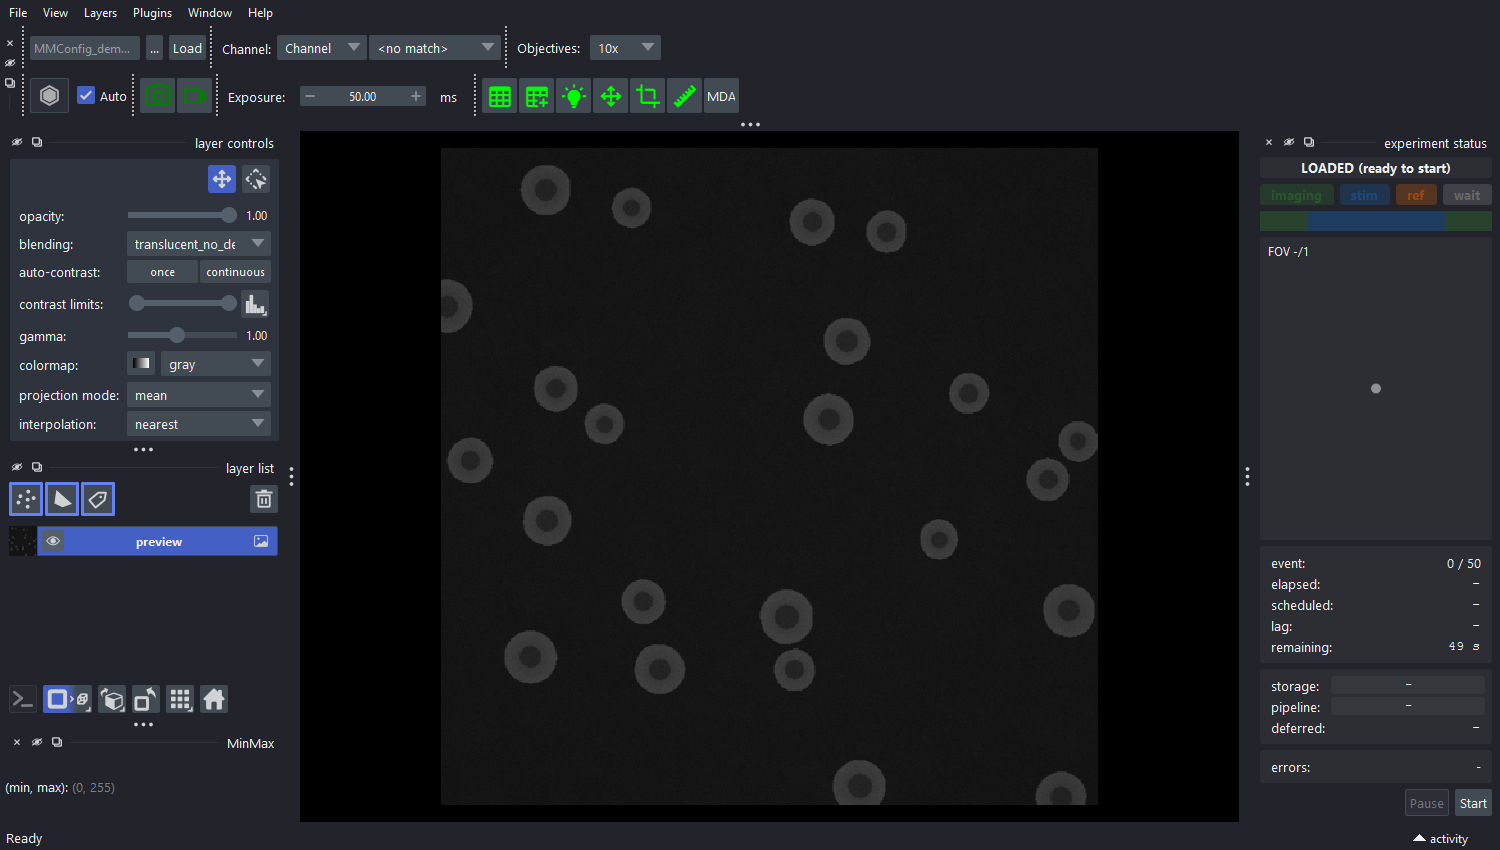

In [14]:
t0 = time.time()
while time.time() - t0 < 1:                          # let the widget redraw
    QApplication.processEvents()
nbscreenshot(viewer, canvas_only=False)

## 11. Run

`start_experiment` starts the loaded run and returns a `RunHandle`; pressing **Start** in the widget does the same. The kernel stays free while the experiment runs, so you can poll the handle, watch napari or add events. `stim_mode="current"` means each stimulation mask is computed from the frame acquired in the same timepoint.

See [Running](../README.md#running) in the README.

In [15]:
handle = ctrl.start_experiment()
handle.status()

RunStatus(state='running', current_event_index=None, current_fov=None, n_events_total=50, n_events_consumed=0, n_events_acquired=0, n_frames_received=0, started_at=None, finished_at=None, last_frame_wallclock=None, lag_ms=None, wait_remaining_s=None, pipeline_inflight=0, storage_queue_depth=0, n_stim_fallbacks=0, background_errors=(), fatal_error=None)

In [16]:
final = handle.wait()
print(f"state {final.state!r}, {final.n_frames_received} frames, "
      f"{len(final.background_errors)} background errors")

state 'done', 50 frames, 0 background errors


An experiment does not have to end when the event list does. At the scope you
look at the results and decide what comes next. `continue_experiment` appends
a new phase and keeps the tracking state, so particle ids carry on. To add
events while a run is still going, use `extend_experiment` instead (see
[Experiment Continuation](../README.md#experiment-continuation)).

In [17]:
extra = RTMSequence(
    time_plan={"interval": INTERVAL_S, "loops": N_EXTRA},
    stage_positions=position,
    channels=imaging,
    rtm_metadata={"phase": "extra-recovery"},
)
extra_status = ctrl.continue_experiment(list(extra), stim_mode="current").wait()
ctrl.finish_experiment()
print(f"state {extra_status.state!r}, {extra_status.n_frames_received} extra frames, "
      f"{len(extra_status.background_errors)} background errors")

2026-09-07 16:02:04,072 INFO faro.core.controller: MDA run started: 10 events, stim_mode=current


state 'done', 10 extra frames, 0 background errors


## 12. Did the cells respond?

Tracks are parquet files, one per field of view, in `tracks/`. Each row is one cell in one frame: `particle` is the track id, `label` the id in that frame's label image, `x` and `y` the centroid, plus the columns your feature extractor returned and the `rtm_metadata` of the event. Images, labels and stimulation masks are in the OME-Zarr store next to it. See [Storage](../README.md#storage) in the README for the full layout.

The stimulator lit the top edge of every cell, so cells should move up (toward smaller row index) during the stimulation phase and drift randomly otherwise.

raw array shape: (60, 2, 512, 512)


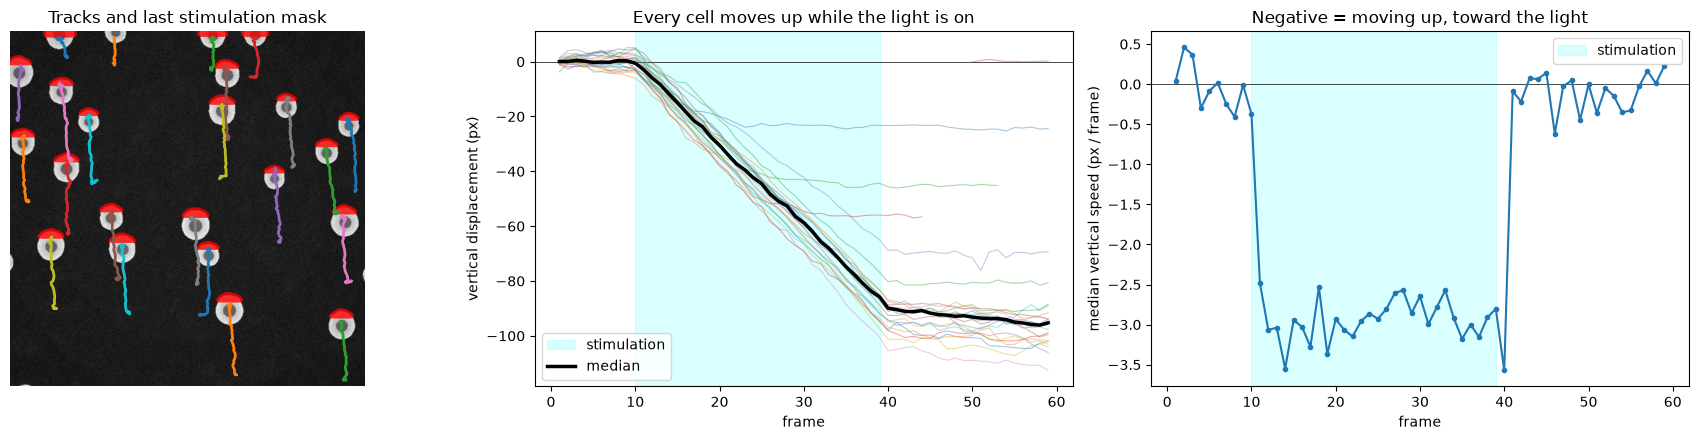

In [18]:
import os
import zarr

tracks = pd.read_parquet(os.path.join(path, "tracks", "0_latest.parquet"))
tracks = tracks.sort_values(["particle", "timestep"])
tracks["dy"] = tracks.groupby("particle")["x"].diff()          # column "x" is the row index
tracks["cum_dy"] = tracks.groupby("particle")["dy"].cumsum()   # displacement since the first frame
speed = tracks.groupby("timestep")["dy"].median()
displacement = tracks.groupby("timestep")["cum_dy"].median()

stim_frames = df_events[df_events["stim"]]["timestep"]
store = zarr.open(os.path.join(path, "acquisition.ome.zarr"), mode="r")
raw = store["0"]   # (t, c, y, x): channel 0 is the image, channel 1 the stim frame
print("raw array shape:", raw.shape)
last_raw = raw[int(stim_frames.max()), 0]
last_mask = store["labels/stim_mask/0"][int(stim_frames.max())]

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
axes[0].imshow(last_raw, cmap="gray")
axes[0].imshow(np.ma.masked_where(last_mask == 0, last_mask), cmap="autumn", alpha=0.8)
for pid, t in tracks.groupby("particle"):
    axes[0].plot(t["y"], t["x"], lw=2)
axes[0].set_title("Tracks and last stimulation mask")
axes[0].axis("off")

for ax in axes[1:]:
    ax.axvspan(stim_frames.min(), stim_frames.max(), color="cyan", alpha=0.15, label="stimulation")
    ax.axhline(0, color="k", lw=0.5)
    ax.set_xlabel("frame")

for pid, t in tracks.groupby("particle"):
    axes[1].plot(t["timestep"], t["cum_dy"], lw=0.8, alpha=0.4)
axes[1].plot(displacement.index, displacement.values, color="k", lw=2.5, label="median")
axes[1].set_ylabel("vertical displacement (px)")
axes[1].set_title("Every cell moves up while the light is on")
axes[1].legend()

axes[2].plot(speed.index, speed.values, "o-", ms=3)
axes[2].set_ylabel("median vertical speed (px / frame)")
axes[2].set_title("Negative = moving up, toward the light")
axes[2].legend()
plt.tight_layout()

## Next steps

- Copy [templates/live_experiment](../templates/live_experiment/) to start a real experiment, or [templates/reanalysis](../templates/reanalysis/) to re-process one on disk.
- Read [Writing your own components](../README.md#writing-your-own-components), [Experiment Definition](../README.md#experiment-definition) and [Storage](../README.md#storage) in the README.
- Swap `StimUp` for a stimulator that uses `tracks`, for example one that steers even and odd `particle` ids in opposite directions.